# Linear Regression Exercise

## Use linear regression on the *bodyfat* dataset

We are going to follow the same pipeline than in the lab session but now with a simple dataset.  

- [ ] Visualize your dataset. Does it have anything strange?
- [ ] Split your dataset in train and test. 
- [ ] Design a pre-processing for your dataset and apply it to your partitions. 
- [ ] Train a Linear Regression model.
- [ ] Train a Ridge Regression model with cross-validation.  
- [ ] Train a Lasso Regression model with cross-validation.  
- [ ] Compare your three models using cross-validation metrics and looking into their weights. Do they show strong differences?
- [ ] Compute the generalization performance of the best model.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV


from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option('display.precision', 3)
np.set_printoptions(precision=3)

In [54]:
bodyfat_data = pd.read_csv("bodyfatdata.txt", 
                        sep=r"\s+", engine="python", 
                        names=['triceps', 'thigh', 'midarm', 'bodyfat'])

print(bodyfat_data.shape)
bodyfat_data.describe()

(20, 4)


,triceps,thigh,midarm,bodyfat
count,20.000,20.000,20.000,20.000
mean,25.305,51.170,27.620,20.195
std,5.023,5.235,3.647,5.106
min,14.600,42.200,21.300,11.700
25%,21.500,47.775,24.750,17.050
50%,25.550,52.000,27.900,21.200
75%,29.900,54.625,30.025,24.275
max,31.400,58.600,37.000,27.200


In [5]:
bodyfat_data.head().sort_values(by='bodyfat')

,triceps,thigh,midarm,bodyfat
0,19.5,43.1,29.1,11.9
4,19.1,42.2,30.9,12.9
2,30.7,51.9,37.0,18.7
3,29.8,54.3,31.1,20.1
1,24.7,49.8,28.2,22.8


## 1. Data Visualization & Exploration

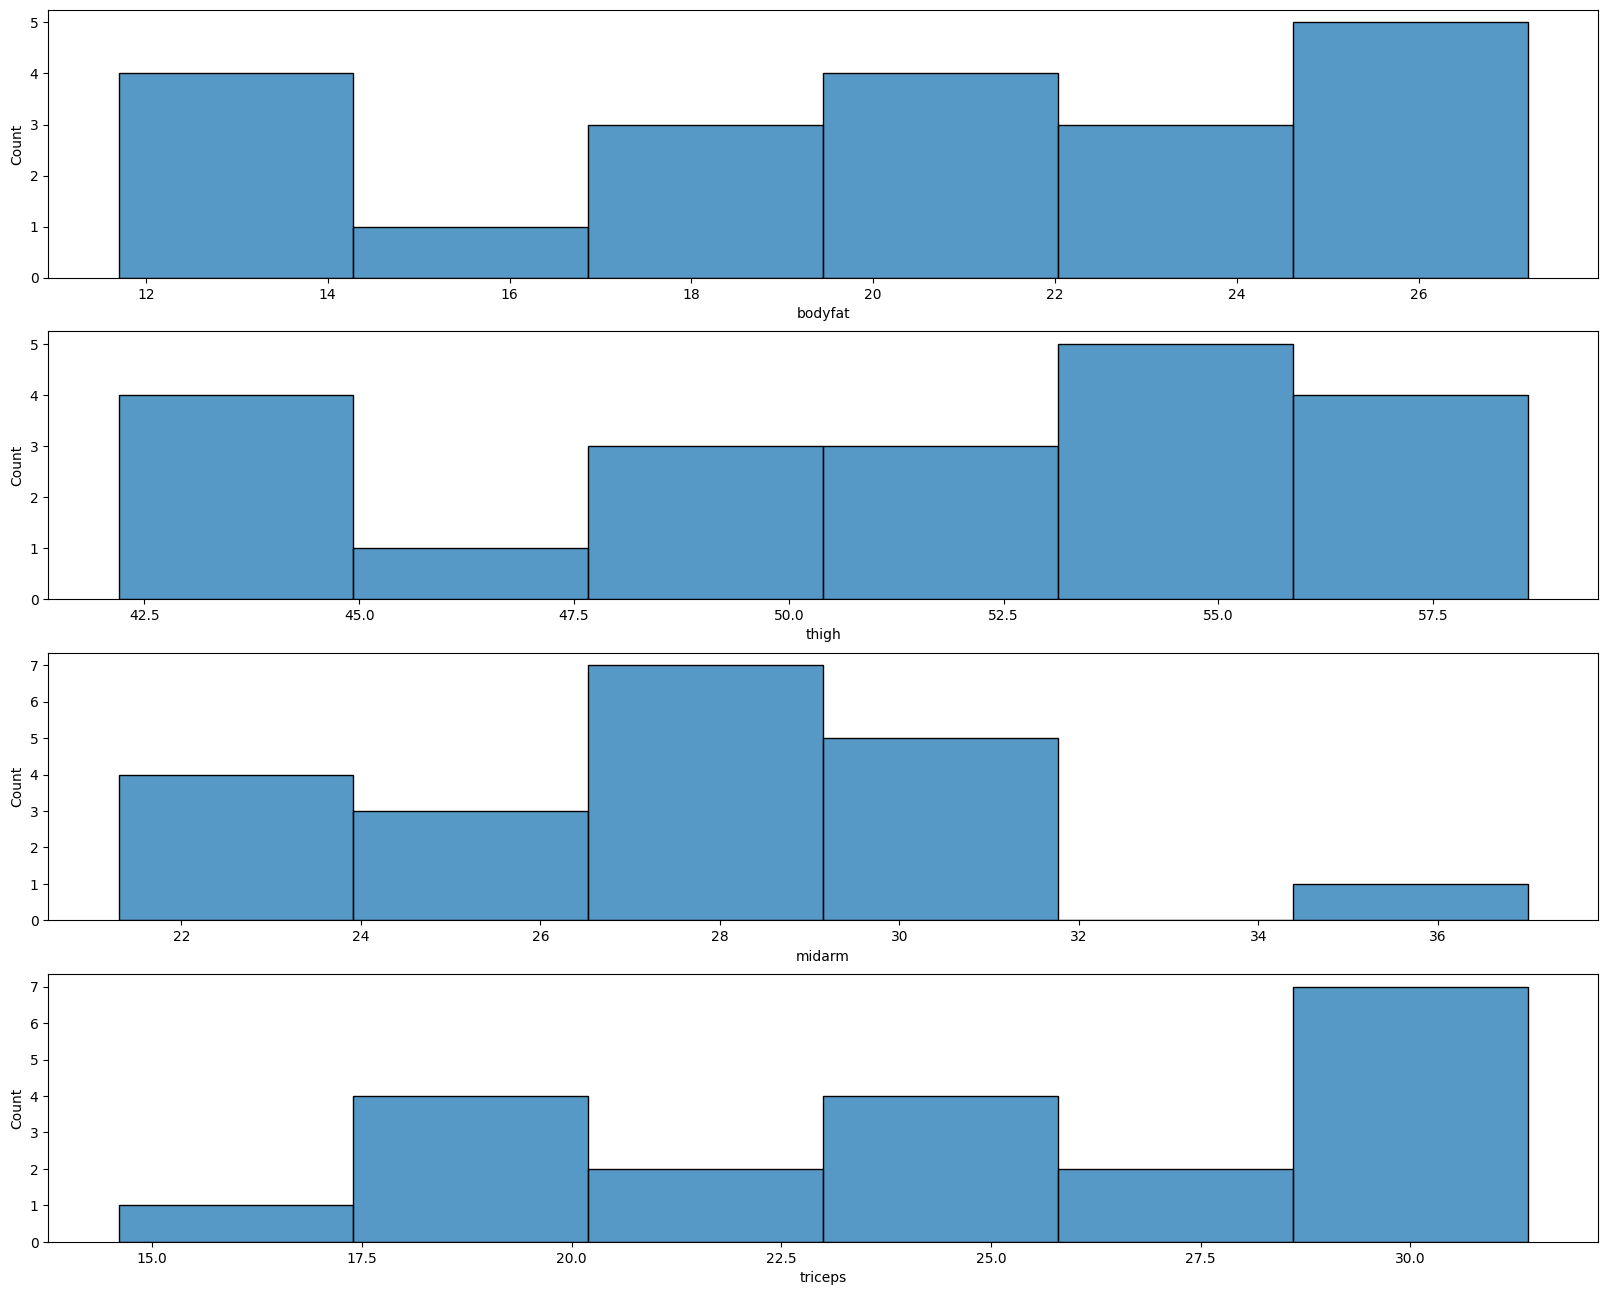

In [18]:
fig, axes = plt.subplots(4, 1, figsize = (20,16))
# Do histograms for numerical variables 
sns.histplot(x=bodyfat_data["bodyfat"],ax=axes[0])
sns.histplot(x=bodyfat_data["thigh"], ax=axes[1])
sns.histplot(x=bodyfat_data["midarm"], ax=axes[2])
sns.histplot(x=bodyfat_data["triceps"], ax=axes[3])

# Actually no categorical variables 

plt.show()

In [36]:
# No null values
print(f"not null?\n {bodyfat_data.notna().count()}")

# No outliers
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)  # First quartile (25%)
    Q3 = df[column].quantile(0.75)  # Third quartile (75%)
    IQR = Q3 - Q1  # Interquartile range
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

print(detect_outliers_iqr(bodyfat_data, "midarm"))
print(detect_outliers_iqr(bodyfat_data, "triceps"))
print(detect_outliers_iqr(bodyfat_data, "thigh"))
print(detect_outliers_iqr(bodyfat_data, "bodyfat"))

not null?
 triceps    20
thigh      20
midarm     20
bodyfat    20
dtype: int64
Empty DataFrame
Columns: [triceps, thigh, midarm, bodyfat]
Index: []
Empty DataFrame
Columns: [triceps, thigh, midarm, bodyfat]
Index: []
Empty DataFrame
Columns: [triceps, thigh, midarm, bodyfat]
Index: []
Empty DataFrame
Columns: [triceps, thigh, midarm, bodyfat]
Index: []


## 2. Preprocessing

In [55]:
scaler = MinMaxScaler()

bodyfat_data[bodyfat_data.columns] = scaler.fit_transform(bodyfat_data[bodyfat_data.columns])

## 3. Data Splitting

In [59]:
x = bodyfat_data.drop(columns=["bodyfat"], inplace=False)
y = bodyfat_data["bodyfat"]
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, train_size=0.8, random_state=42)

## 3. Data Preprocessing

## 4. Model 1: Linear

In [66]:
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

yh_lr = linear_model.predict(x_test)
mse_lr = mean_squared_error(yh_lr, y_test); mse_lr

0.021595857600682288

## 5. Model 2: RidgeCV

In [68]:
# Ridge has 1 additional hyperparamter lambda/alpha
# Additionally the number of cross validation folds to generate
lambdas = [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 0.5, 1, 5, 10]
ridge_model = RidgeCV(alphas=lambdas, cv=5)

ridge_model.fit(x_train, y_train)
yh_rcv = ridge_model.predict(x_test)
mse_rcv = mean_squared_error(yh_rcv, y_test); mse_rcv


0.08735192465554265

## 6. Model 3: LassoCV

In [70]:
lasso_model = LassoCV(alphas=lambdas, cv=5, verbose=False)
lasso_model.fit(x_train, y_train)

yh_lcv = lasso_model.predict(x_test)
mse_lcv = mean_squared_error(yh_lcv, y_test); mse_lcv

/home/wtroiani/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.02408482939609949, tolerance: 0.00013023378425251476
  model = cd_fast.enet_coordinate_descent_gram(
/home/wtroiani/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.10925493808308333, tolerance: 0.00013023378425251476
  model = cd_fast.enet_coordinate_descent_gram(
/home/wtroiani/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.05554555581932928, tolerance: 0.00014068294244777075
  model = cd_fast.enet_coordinate_descent_gram(
/home/wtroiani/miniconda3/lib/python3

0.018780195133966775

# 7. Comparison

Lets look at their weights to find notable differences and compute their generalized cross validation approximation.

In [73]:
print(f"linear model: {linear_model.coef_} {linear_model.intercept_}")
print(f"ridge model: {ridge_model.coef_} {ridge_model.intercept_}")
print(f"lasso model: {lasso_model.coef_} {lasso_model.intercept_}")

linear model: [ 6.112 -4.239 -2.906] 0.151999321251862
ridge model: [0.096 0.103 0.017] 0.41250820377152597
lasso model: [ 0.199  0.711 -0.   ] 0.02437541559983425


## Advanced Exercise: Try to improve the results of the lab session

There are some points that could be improved from the lab session. 
- [ ] Linear regression is strongly affected by outliers. Design a strategy for removing outliers. Does it improve the validation metrics with respect to the best ones of the lab. 
- [ ] We have ignored (almost) completely our missing values. Design a strategy for handling missing values. Does it improve the validation metrics with respect to the best ones of the lab.   
- [ ] Some variables are not looking gaussian. Transforming them could improve your model performance. Does this improve validation metrics and/or generalization of the best model?

In [4]:
life_expentancy_data = pd.read_csv('Life_Expectancy_Data.csv')
# We remove spaces and symbols to avoid problems with statsmodel GLM
life_expentancy_data.columns = [c.lower().strip().replace(' ','_').replace('/','_').replace('-','_') for c in life_expentancy_data.columns] 

# We change the type of categorical variables into category
categorical_columns = list(life_expentancy_data.dtypes[life_expentancy_data.dtypes == 'O'].index.values)
for column in categorical_columns:
    life_expentancy_data[column] = life_expentancy_data[column].astype('category')

life_expentancy_data.head()

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness__1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.280,65.0,1154,...,6.0,8.16,65.0,0.1,584.259,3.374e+07,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.524,62.0,492,...,58.0,8.18,62.0,0.1,612.697,3.276e+05,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219,64.0,430,...,62.0,8.13,64.0,0.1,631.745,3.173e+07,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184,67.0,2787,...,67.0,8.52,67.0,0.1,669.959,3.697e+06,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097,68.0,3013,...,68.0,7.87,68.0,0.1,63.537,2.979e+06,18.2,18.2,0.454,9.5
